# Bai 1: Phan loai Email Spam / Not-Spam bang N-gram + Machine Learning

**Quy trinh:** Tien xu ly -> Tokenization -> Encoding bang **N-gram (CountVectorizer)** -> Mo hinh ML (Naive Bayes, Logistic Regression).

Dataset: `spam_or_not_spam.csv` (cot `email`, `label`; 0 = not spam, 1 = spam).

## Cell 1 - Import thu vien

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cau hinh chung
CONFIG = {
    "csv_path": "spam_or_not_spam.csv",
    "test_size": 0.2,
    "random_state": 42,
    "ngram_range": (1, 2),   # unigram + bigram
    "min_df": 2,
}
print("Da import xong thu vien.")

Da import xong thu vien.


## Cell 2 - Get data (doc du lieu)

In [2]:
def load_data(csv_path):
    """Doc file CSV -> DataFrame gom 2 cot: email, label."""
    return pd.read_csv(csv_path)

df = load_data(CONFIG["csv_path"])
print("Kich thuoc du lieu:", df.shape)
print("Phan bo nhan:")
print(df["label"].value_counts())
df.head()

Kich thuoc du lieu: (3000, 2)
Phan bo nhan:
label
0    2500
1     500
Name: count, dtype: int64


,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


## Cell 3 - Xu ly (lam sach & tien xu ly van ban)

In [3]:
def clean_text(text):
    """Lam sach 1 email: viet thuong, chi giu chu cai, gom khoang trang."""
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)   # bo so & ky tu dac biet
    text = re.sub(r"\s+", " ", text)         # gom khoang trang
    return text.strip()

def preprocess(df):
    """Bo dong NaN/rong va them cot 'clean'."""
    df = df.dropna(subset=["email"]).copy()
    df["clean"] = df["email"].apply(clean_text)
    df = df[df["clean"].str.len() > 0]
    return df

df = preprocess(df)
print("Sau lam sach:", df.shape[0], "email")
print("Vi du email da lam sach:")
print(df["clean"].iloc[0][:120], "...")

Sau lam sach: 2997 email
Vi du email da lam sach:
date wed number aug number number number number number from chris garrigues cwg dated number numberfanumberd deepeddy co ...


## Cell 4 - Class & ham (bo phan loai N-gram + ML)

In [4]:
class SpamClassifier:
    """Encoding bang N-gram (CountVectorizer) + mo hinh ML."""

    def __init__(self, ngram_range=(1, 2), min_df=2, model=None):
        self.vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
        self.model = model if model is not None else MultinomialNB()

    def fit(self, texts, labels):
        X = self.vectorizer.fit_transform(texts)  # hoc tu dien n-gram + dem tan suat
        self.model.fit(X, labels)
        return self

    def predict(self, texts):
        X = self.vectorizer.transform(texts)
        return self.model.predict(X)

    def vocab_size(self):
        return len(self.vectorizer.vocabulary_)

print("Da dinh nghia class SpamClassifier.")

Da dinh nghia class SpamClassifier.


## Cell 5 - Utils (ham tien ich danh gia & ve bieu do)

In [5]:
def evaluate(y_true, y_pred):
    """In bao cao va tra ve accuracy."""
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=["not spam", "spam"]))
    return acc

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    """Ve ma tran nham lan."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["not spam", "spam"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["not spam", "spam"])
    ax.set_xlabel("Du doan"); ax.set_ylabel("Thuc te"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="red", fontsize=14)
    plt.tight_layout()
    return fig

print("Da dinh nghia ham utils.")

Da dinh nghia ham utils.


## Cell 6 - Main (trinh tu lam theo de)

In [6]:
# B1. Chia train / test (giu nguyen ti le spam/not-spam)
X_train, X_test, y_train, y_test = train_test_split(
    df["clean"], df["label"],
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=df["label"],
)

# B2. Huan luyen N-gram + Naive Bayes
clf_nb = SpamClassifier(CONFIG["ngram_range"], CONFIG["min_df"], MultinomialNB())
clf_nb.fit(X_train, y_train)
print("So dac trung n-gram:", clf_nb.vocab_size())

print("\n=== N-gram + Naive Bayes ===")
y_pred_nb = clf_nb.predict(X_test)
acc_nb = evaluate(y_test, y_pred_nb)

# B3. Huan luyen N-gram + Logistic Regression de so sanh mo hinh
clf_lr = SpamClassifier(CONFIG["ngram_range"], CONFIG["min_df"], LogisticRegression(max_iter=1000))
clf_lr.fit(X_train, y_train)
print("=== N-gram + Logistic Regression ===")
y_pred_lr = clf_lr.predict(X_test)
acc_lr = evaluate(y_test, y_pred_lr)

So dac trung n-gram: 81858

=== N-gram + Naive Bayes ===
Accuracy: 0.9933
              precision    recall  f1-score   support

    not spam       0.99      1.00      1.00       501
        spam       1.00      0.96      0.98        99

    accuracy                           0.99       600
   macro avg       1.00      0.98      0.99       600
weighted avg       0.99      0.99      0.99       600



=== N-gram + Logistic Regression ===
Accuracy: 0.9917
              precision    recall  f1-score   support

    not spam       0.99      1.00      1.00       501
        spam       1.00      0.95      0.97        99

    accuracy                           0.99       600
   macro avg       1.00      0.97      0.98       600
weighted avg       0.99      0.99      0.99       600



## Cell 7 - Show bieu do

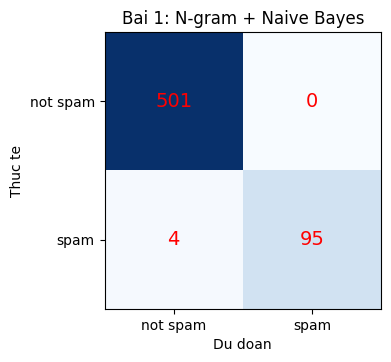

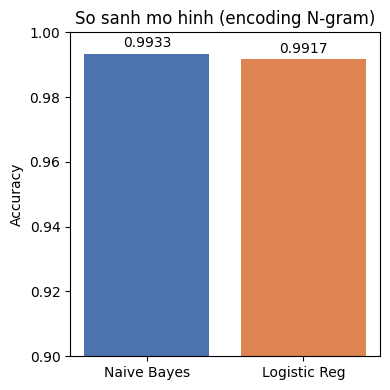

In [7]:
# Bieu do 1: confusion matrix cua mo hinh tot nhat (Naive Bayes)
plot_confusion(y_test, y_pred_nb, title="Bai 1: N-gram + Naive Bayes")
plt.show()

# Bieu do 2: so sanh accuracy 2 mo hinh
plt.figure(figsize=(4, 4))
plt.bar(["Naive Bayes", "Logistic Reg"], [acc_nb, acc_lr], color=["#4c72b0", "#dd8452"])
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("So sanh mo hinh (encoding N-gram)")
for i, v in enumerate([acc_nb, acc_lr]):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.show()